# Network Visualization with NetworkX: A Practical Tutorial

**CMSE 402 — Data Visualization Principles and Techniques**  
**Honors Option Project**

---
## Why this tutorial?

Many existing NetworkX tutorials focus mainly on how to construct graphs and use specific functions. However, they often do not explain how visualization choices affect interpretation.

This tutorial is designed to fill that gap by combining:
- graph construction and analysis
- visualization design decisions
- interpretation of results

The goal is not only to show how to draw a network, but to explain how to design network visualizations so that patterns and structure are easier to understand.

## Overview

Network (or graph) data is fundamentally different from tabular data: it encodes not just *attributes* of individual entities, but the **relationships between them**. Choosing the right layout algorithm, color encoding, and analytical metric can reveal structure that would be completely invisible in a simple table or scatter plot.

This tutorial walks through a full network visualization workflow using [NetworkX](https://networkx.org/), a powerful Python library for network analysis. We'll use the **Hartford, CT drug-use network** — a real-world directed graph built from two years of observations of acquaintanceship among drug users.

### What you'll learn

1. How to load and inspect network data
2. How different **layout algorithms** reveal different structures (and why that matters)
3. How to visualize **degree distributions** (in-degree vs. out-degree in directed graphs)
4. How to compute and visualize **clustering coefficients**
5. How to compute and map **centrality metrics** (closeness & betweenness)
6. How to highlight **shortest paths** through a graph
7. How to build a **multi-panel summary figure** that tells the full story

### Connection to course assignments

This tutorial builds directly on:
- **PCA 21**: Introduction to NetworkX — creating graphs, directed graphs, reading GML files, and using PyGraphviz layouts
- **ICA 21**: Analysis of the Hartford drug network — degree distributions, clustering, centrality, and shortest paths
- **Data Visualization Catalogue** readings on network diagrams, arc diagrams, and chord diagrams
- Course principles on **visual encoding**: mapping data attributes to color, size, and position purposefully

## Connection to course readings

This tutorial applies several ideas from the course readings on data visualization.

It emphasizes clarity and meaningful design, following Cairo’s idea that visualizations should communicate information rather than simply display data. It also reflects Tufte’s principle of reducing unnecessary visual clutter so that important patterns are easier to see.

Visual encodings such as color and size are used carefully to represent quantitative differences, which connects to ideas about perception discussed in class. For example, sequential colormaps are used for positive-valued metrics so that stronger color intensity represents larger values.

The use of consistent node positions across multiple panels reflects the importance of comparability, allowing viewers to track the same nodes across different metrics.

## Connection to course work

This tutorial builds on course activities from PCA 21 and ICA 21, where we worked with network data using NetworkX, including the Hartford drug-use dataset and the Les Misérables network.

The tutorial extends those activities by focusing more on visualization design. Instead of only generating graphs, it compares layouts, applies multiple metrics, and explains how different design choices affect interpretation.

---

## Dataset

The **Hartford drug network** (`hartford_drug.txt`) is a directed graph of acquaintanceship among drug users in Hartford, CT, collected over two years of ethnographic observation. Each directed edge `A → B` means person A considers person B an acquaintance.

> 📚 **Citation**: Weeks, M.R., et al. (2002). Social Networks of Drug Users in High-Risk Sites. *AIDS and Behavior*, 6(2), 193–206.

The dataset is edge-list format: each line contains two node IDs separated by whitespace.

---

## Part 0: Setup & Imports

We need `networkx` for graph analysis, `matplotlib` for plotting, and `numpy` for numerical summaries. If you don't have NetworkX, install it with `pip install networkx`.

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Consistent, publication-quality style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("NetworkX version:", nx.__version__)
print("All imports successful.")

NetworkX version: 3.3
All imports successful.


---

## Part 1: Loading the Data

NetworkX can read edge-list files directly with `nx.read_edgelist()`. Since the Hartford dataset is a **directed** graph (person A knowing person B doesn't necessarily mean B knows A), we use `create_using=nx.DiGraph()`.

### Why directed graphs matter for visualization

In an undirected graph, an edge is symmetric — it just means "connected." In a directed graph, each edge has a *source* and a *target*, which opens up new metrics:
- **In-degree**: how many people point *to* you (your "popularity" or influence received)
- **Out-degree**: how many people you point *to* (your social reach or outreach)

In [6]:
# Load the directed graph from edge list
G = nx.read_edgelist(
    "hartford_drug.txt",
    create_using=nx.DiGraph(),  # directed graph
    nodetype=int                # nodes are integers, not strings
)

# Basic statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = num_edges / num_nodes

print(f"Graph order (nodes): {num_nodes}")
print(f"Graph size (edges):  {num_edges}")
print(f"Average degree:      {avg_degree:.2f}")
print(f"Graph type:          {'Directed' if G.is_directed() else 'Undirected'}")

Graph order (nodes): 212
Graph size (edges):  337
Average degree:      1.59
Graph type:          Directed


> 💡 **Interpretation**: The average degree tells us how densely connected the network is on average. As connectivity increases (e.g., in a fully connected graph), the average degree approaches `N-1` (every node connected to every other). Here, with ~212 nodes and ~284 edges, the average degree is low — this is a **sparse** network, which is typical of social networks.

---

## Part 2: Layout Algorithms — Why They Matter

One of the most important (and underappreciated) decisions in network visualization is choosing a **layout algorithm**. The algorithm determines the 2D positions of the nodes — there is no single "correct" answer, and different algorithms reveal different structures.

According to the **Data Visualization Catalogue**, network diagrams are best read when:
- Clusters (densely connected subgroups) are visually separated
- Important nodes are visually prominent
- Edge crossings are minimized

Different layout algorithms optimize for different goals. Let's compare three:

| Layout | Algorithm | Best for |
|---|---|---|
| Spring / Fruchterman-Reingold | Force-directed (repulsion + attraction) | General structure, clusters |
| Circular | Places nodes on a circle | Showing all edges equally |
| Kamada-Kawai | Spring model with geodesic distances | Revealing overall topology |

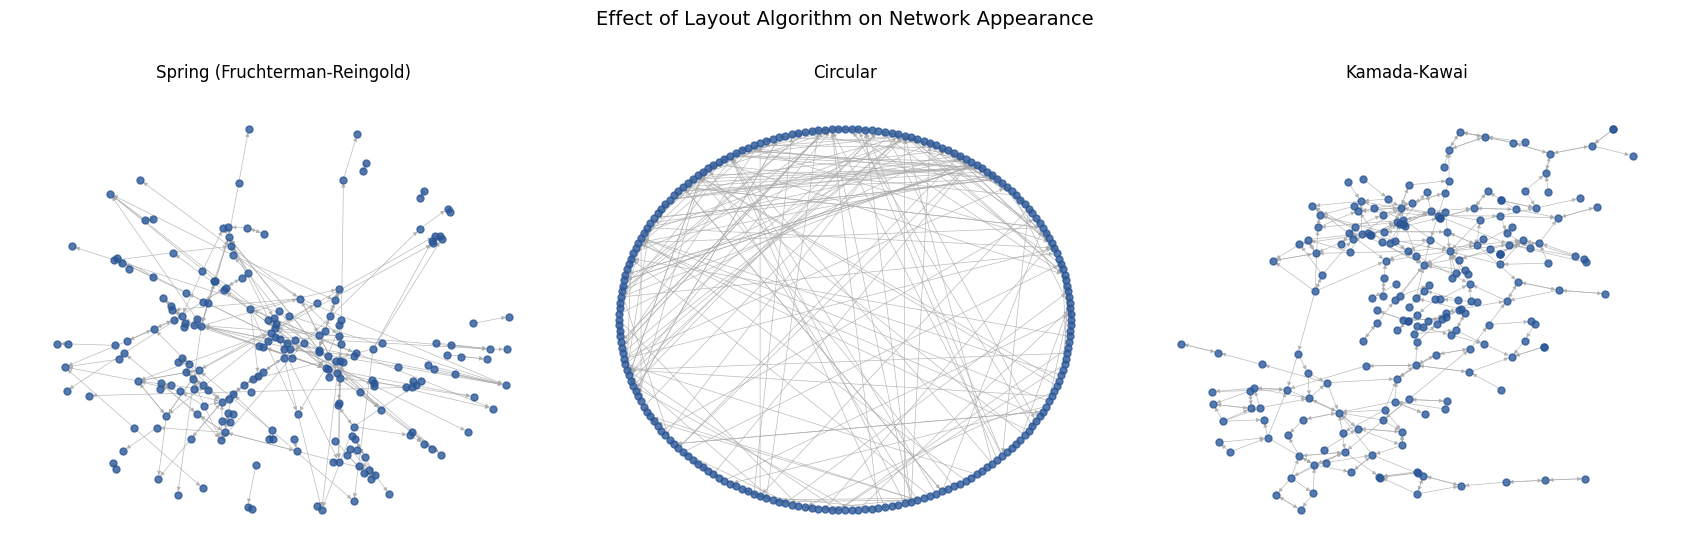

Saved: layout_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle("Effect of Layout Algorithm on Network Appearance", fontsize=14, y=1.01)

DRAW_PARAMS = dict(
    node_size=25,
    node_color='#2b5797',
    edge_color='#aaaaaa',
    arrows=True,
    arrowsize=6,
    width=0.5,
    alpha=0.8
)

layouts = [
    ("Spring (Fruchterman-Reingold)", nx.spring_layout(G, seed=42)),
    ("Circular",                      nx.circular_layout(G)),
    ("Kamada-Kawai",                  nx.kamada_kawai_layout(G)),
]

for ax, (title, pos) in zip(axes, layouts):
    nx.draw(G, pos=pos, ax=ax, **DRAW_PARAMS)
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig("layout_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: layout_comparison.png")

> 🔍 **What to notice**:
> - The **spring layout** tends to pull tightly-connected clusters together and push isolated nodes outward — this is the best choice for revealing community structure.
> - The **circular layout** places all nodes equidistantly on a ring. This minimizes layout bias, but makes it hard to see clusters; it works better for small or highly regular graphs.
> - The **Kamada-Kawai** layout tries to position nodes so that graph-theoretic distances map to geometric distances. It's computationally expensive but often produces aesthetically pleasing results.

**For the rest of this tutorial, we'll use the spring layout**, which best reveals the community structure of the Hartford network.

In [10]:
# Compute and store the spring layout — we'll reuse this throughout
POS = nx.spring_layout(G, seed=42)

---

## Part 3: Degree Distribution

The **degree** of a node is the number of edges connected to it. For directed graphs, we distinguish:
- **In-degree**: edges *arriving at* a node (how many people list you as an acquaintance)
- **Out-degree**: edges *leaving from* a node (how many acquaintances you list)

Plotting the **degree distribution** as a histogram reveals whether the network has a few highly-connected "hubs" or whether connections are more evenly spread. Many real-world social networks follow a **power-law** distribution — most nodes have few connections, but a small number of nodes have very many.

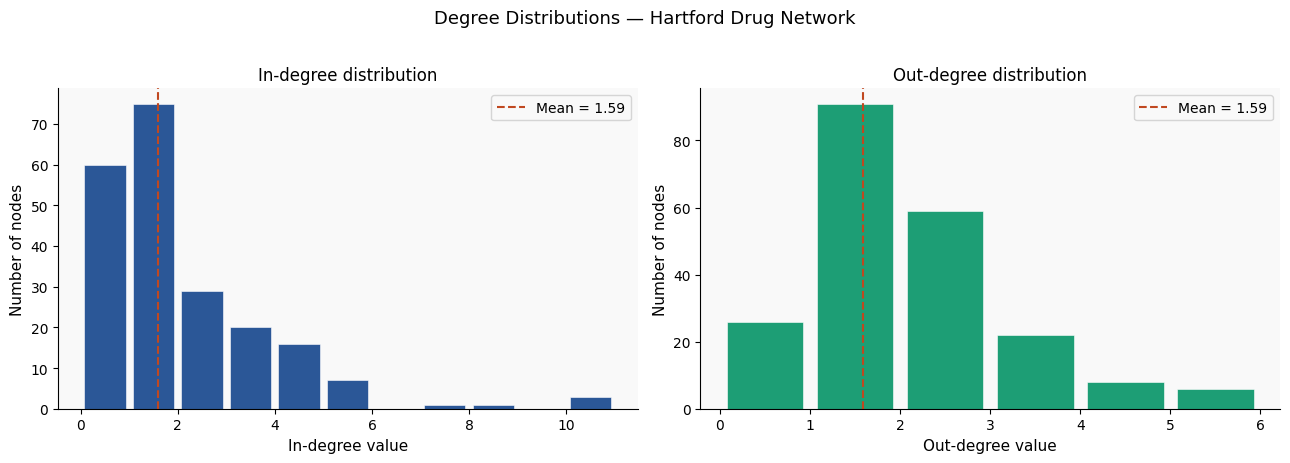

In-degree  — min: 0, max: 10, mean: 1.59
Out-degree — min: 0, max: 5, mean: 1.59


In [12]:
# Extract degree values as lists
# .in_degree() returns a DegreeView (like a dict), so we use dict() then .values()
in_degrees  = list(dict(G.in_degree()).values())
out_degrees = list(dict(G.out_degree()).values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

def plot_degree_hist(ax, degrees, label, color):
    bins = range(0, max(degrees) + 2)
    ax.hist(degrees, bins=bins, color=color, edgecolor='white', linewidth=0.4, rwidth=0.85)
    ax.set_xlabel(f"{label} value", fontsize=11)
    ax.set_ylabel("Number of nodes", fontsize=11)
    ax.set_title(f"{label} distribution", fontsize=12)
    mean_val = np.mean(degrees)
    ax.axvline(mean_val, color='#c04820', linestyle='--', linewidth=1.5,
               label=f"Mean = {mean_val:.2f}")
    ax.legend(fontsize=10)

plot_degree_hist(axes[0], in_degrees,  "In-degree",  "#2b5797")
plot_degree_hist(axes[1], out_degrees, "Out-degree", "#1d9e75")

fig.suptitle("Degree Distributions — Hartford Drug Network", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("degree_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"In-degree  — min: {min(in_degrees)}, max: {max(in_degrees)}, mean: {np.mean(in_degrees):.2f}")
print(f"Out-degree — min: {min(out_degrees)}, max: {max(out_degrees)}, mean: {np.mean(out_degrees):.2f}")

> 💡 **Interpretation**: Both distributions are **right-skewed** — most nodes have a small number of connections, but a few nodes have many. This is characteristic of real-world social networks. The distribution also hints at whether the network has clear "hubs" (very high-degree nodes) that might be targets for public health intervention.
>
> Notice that in-degree and out-degree distributions can differ: if most people name a few specific popular individuals (high in-degree), but spread their own outgoing nominations broadly, the shapes will diverge.

---

## Part 4: Highlighting Most and Least Connected Nodes

Identifying the extreme nodes is useful for both analysis and for **encoding structure into the visualization**. According to course principles on preattentive attributes, differences in **color** and **size** are among the most effective channels for drawing attention to specific nodes.

Here we'll use *total degree* (in + out) to find the most- and least-connected individuals.

In [14]:
total_degree = dict(G.degree())

max_deg = max(total_degree.values())
min_deg = min(total_degree.values())

most_connected  = [n for n, d in total_degree.items() if d == max_deg]
least_connected = [n for n, d in total_degree.items() if d == min_deg]

print(f"Most connected nodes:  {most_connected} (degree {max_deg})")
print(f"Least connected nodes: {least_connected[:5]}... (degree {min_deg})")
print(f"Number of isolates (degree=1): {len(least_connected)}")

Most connected nodes:  [50] (degree 15)
Least connected nodes: [209, 5, 12, 27, 40]... (degree 1)
Number of isolates (degree=1): 54


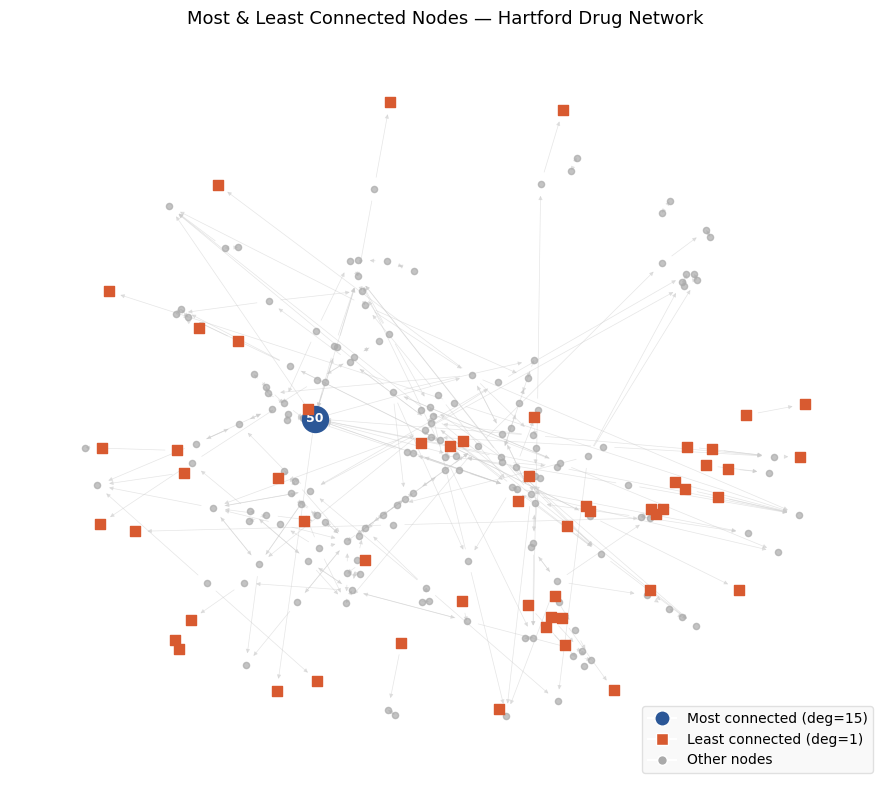

In [16]:
fig, ax = plt.subplots(figsize=(9, 8))

# Draw background edges and regular nodes
nx.draw_networkx_edges(G, POS, ax=ax, edge_color='#cccccc', arrows=True,
                       arrowsize=6, width=0.5, alpha=0.5)
nx.draw_networkx_nodes(G, POS, ax=ax, node_size=20,
                       node_color='#aaaaaa', alpha=0.7)

# Highlight most connected — large blue circles
nx.draw_networkx_nodes(G, POS, ax=ax, nodelist=most_connected,
                       node_size=350, node_color='#2b5797')

# Highlight least connected — orange squares (use marker trick with scatter)
lc_x = [POS[n][0] for n in least_connected]
lc_y = [POS[n][1] for n in least_connected]
ax.scatter(lc_x, lc_y, s=55, c='#d85a30', marker='s',
           zorder=5, label=f'Least connected (deg={min_deg})')

# Labels for most connected only
nx.draw_networkx_labels(G, POS, ax=ax,
                        labels={n: str(n) for n in most_connected},
                        font_size=9, font_color='white', font_weight='bold')

# Legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2b5797',
           markersize=11, label=f'Most connected (deg={max_deg})'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#d85a30',
           markersize=8, label=f'Least connected (deg={min_deg})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#aaaaaa',
           markersize=7, label='Other nodes'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='#dddddd')

ax.set_title("Most & Least Connected Nodes — Hartford Drug Network", fontsize=13, pad=10)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("connected_nodes.png", dpi=150, bbox_inches='tight')
plt.show()

> 🔍 **Design note**: We used **size** (large vs. small nodes) and **color** (blue vs. orange/gray) together to highlight the extremes. Using two channels simultaneously — a technique known as **redundant encoding** — makes the most important nodes even easier to spot, following the principle that preattentive features should reinforce each other for critical data.

---

## Part 5: Clustering Coefficient

The **clustering coefficient** of a node measures how tightly connected that node's neighbors are to each other — essentially, how "clique-like" its neighborhood is.

- **Value = 0**: none of the node's neighbors are connected to each other
- **Value = 1**: all of the node's neighbors are connected to each other (a perfect clique)

Since clustering is typically defined for undirected graphs, we first convert our directed graph using `.to_undirected()`.

Mapping clustering coefficient to **node color** is a powerful example of using a **continuous color scale** to encode a quantitative attribute — a key technique from course discussions on color as an encoding channel.

In [18]:
# Convert to undirected for clustering computation
G_undirected = G.to_undirected()

# nx.clustering() returns a {node: coefficient} dict
clustering = nx.clustering(G_undirected)
clust_values = list(clustering.values())

print(f"Clustering coefficient — min:  {min(clust_values):.4f}")
print(f"Clustering coefficient — max:  {max(clust_values):.4f}")
print(f"Clustering coefficient — mean: {np.mean(clust_values):.4f}")

most_clustered  = [n for n, v in clustering.items() if v == max(clust_values)]
least_clustered = [n for n, v in clustering.items() if v == 0.0]
print(f"\nNodes with max clustering (={max(clust_values):.3f}): {most_clustered}")
print(f"Nodes with zero clustering: {len(least_clustered)} nodes")

Clustering coefficient — min:  0.0000
Clustering coefficient — max:  1.0000
Clustering coefficient — mean: 0.1252

Nodes with max clustering (=1.000): [17, 70, 215, 76, 121, 138, 167, 192, 197, 208, 230, 234]
Nodes with zero clustering: 146 nodes


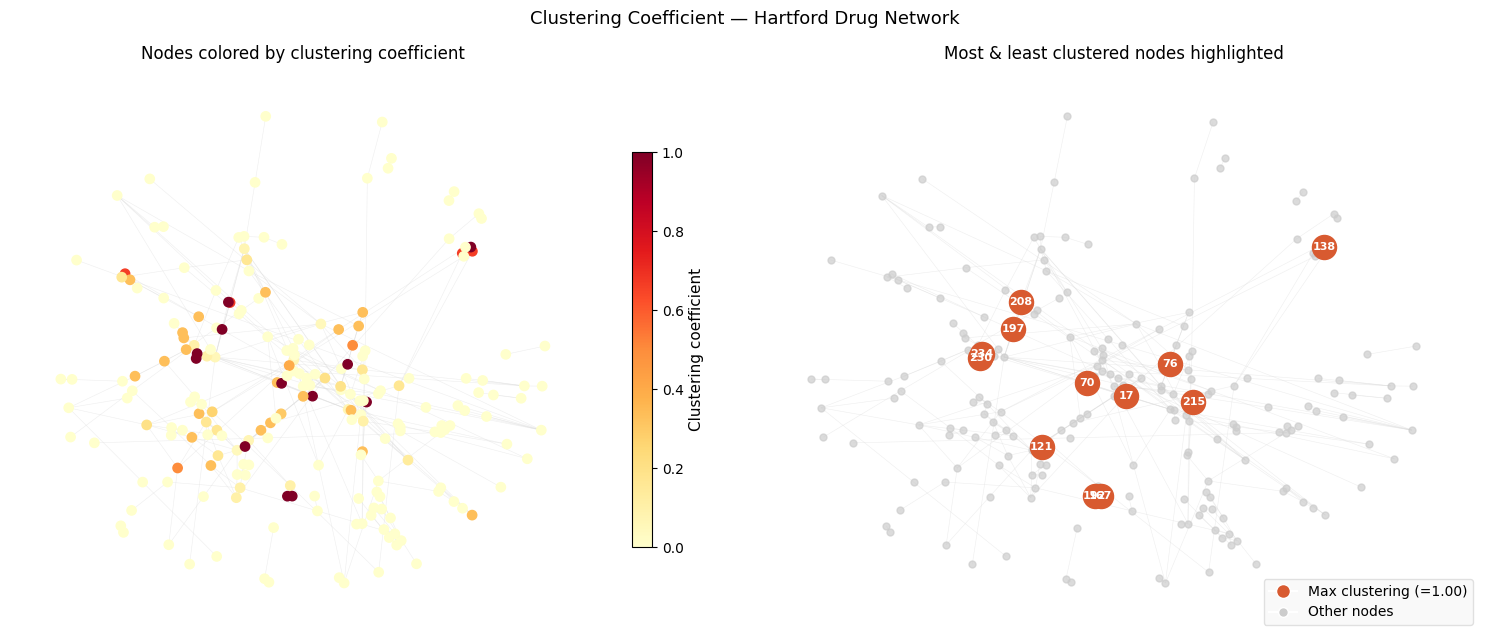

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# --- Left panel: color-mapped clustering ---
ax = axes[0]
node_colors = [clustering[n] for n in G_undirected.nodes()]
nx.draw_networkx_edges(G_undirected, POS, ax=ax, edge_color='#dddddd',
                       width=0.4, alpha=0.5)
sc = nx.draw_networkx_nodes(G_undirected, POS, ax=ax,
                             node_color=node_colors, node_size=45,
                             cmap=plt.cm.YlOrRd, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, shrink=0.7, label='Clustering coefficient')
ax.set_title("Nodes colored by clustering coefficient", fontsize=12)
ax.set_axis_off()

# --- Right panel: most/least clustered highlighted ---
ax2 = axes[1]
nx.draw_networkx_edges(G_undirected, POS, ax=ax2, edge_color='#dddddd',
                       width=0.4, alpha=0.5)
nx.draw_networkx_nodes(G_undirected, POS, ax=ax2, node_size=25,
                       node_color='#cccccc', alpha=0.7)
# Most clustered
nx.draw_networkx_nodes(G_undirected, POS, ax=ax2, nodelist=most_clustered,
                       node_size=300, node_color='#d85a30')
nx.draw_networkx_labels(G_undirected, POS, ax=ax2,
                        labels={n: str(n) for n in most_clustered},
                        font_size=8, font_color='white', font_weight='bold')

legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#d85a30',
           markersize=10, label=f'Max clustering (={max(clust_values):.2f})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#cccccc',
           markersize=7, label='Other nodes'),
]
ax2.legend(handles=legend_handles, loc='lower right', fontsize=10,
           framealpha=0.9, edgecolor='#dddddd')
ax2.set_title("Most & least clustered nodes highlighted", fontsize=12)
ax2.set_axis_off()

fig.suptitle("Clustering Coefficient — Hartford Drug Network", fontsize=13)
plt.tight_layout()
plt.savefig("clustering.png", dpi=150, bbox_inches='tight')
plt.show()

> 💡 **Interpretation**: Nodes with high clustering tend to be embedded in tight local communities — their neighbors all know each other. In the context of disease/drug-use network analysis, **high-clustering nodes** may be embedded in dense social cliques that accelerate the spread of behaviors within the group.
>
> **Design note**: The left panel uses a **sequential colormap** (YlOrRd) to encode the continuous clustering value — a well-suited choice since the values have a natural ordering from 0 to 1, and we care about the high end. This follows the Data Visualization Catalogue guidance on choosing colormaps that match the data's perceptual structure.

---

## Part 6: Centrality Metrics

**Centrality** answers the question: *which nodes are most "important" in the network?* But "important" has multiple meanings — NetworkX provides many centrality metrics. Here we focus on two with complementary interpretations:

### Closeness centrality
A node has high closeness centrality if it can quickly reach all other nodes. Formally:
$$C_{closeness}(v) = \frac{n-1}{\sum_{u \neq v} d(u,v)}$$
where $d(u,v)$ is the shortest-path distance between nodes $u$ and $v$.

→ High closeness = **central hub**, information flows through this node quickly

### Betweenness centrality
A node has high betweenness centrality if many shortest paths between *other* pairs of nodes pass through it. Formally:
$$C_{between}(v) = \sum_{s \neq v \neq t} \frac{\sigma(s,t|v)}{\sigma(s,t)}$$
where $\sigma(s,t)$ is the total number of shortest paths from $s$ to $t$.

→ High betweenness = **bridge node** or **broker**, controlling information flow between communities

In [24]:
print("Computing centrality metrics (this may take a moment for large graphs)...")
closeness    = nx.closeness_centrality(G)
betweenness  = nx.betweenness_centrality(G, normalized=True)

max_close = max(closeness.values())
max_btw   = max(betweenness.values())

most_close   = [n for n, v in closeness.items()   if v == max_close]
most_between = [n for n, v in betweenness.items() if v == max_btw]

print(f"\nMost central by closeness:    node(s) {most_close}, value = {max_close:.4f}")
print(f"Most central by betweenness:  node(s) {most_between}, value = {max_btw:.4f}")

Computing centrality metrics (this may take a moment for large graphs)...

Most central by closeness:    node(s) [38], value = 0.0804
Most central by betweenness:  node(s) [50], value = 0.0593


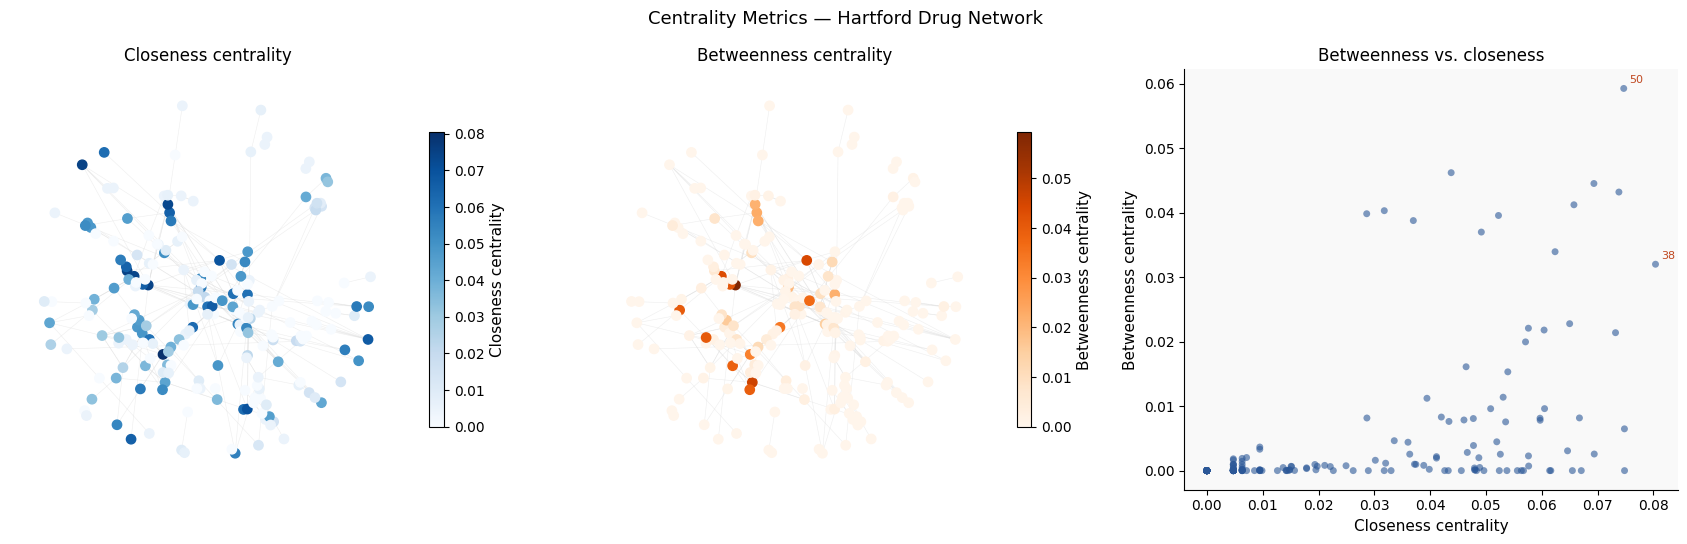

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# --- Panel 1: Closeness centrality heatmap ---
ax = axes[0]
close_vals = [closeness[n] for n in G.nodes()]
nx.draw_networkx_edges(G, POS, ax=ax, edge_color='#dddddd', arrows=False,
                       width=0.4, alpha=0.5)
sc1 = nx.draw_networkx_nodes(G, POS, ax=ax, node_color=close_vals,
                              node_size=45, cmap=plt.cm.Blues, vmin=0)
plt.colorbar(sc1, ax=ax, shrink=0.7, label='Closeness centrality')
ax.set_title("Closeness centrality", fontsize=12)
ax.set_axis_off()

# --- Panel 2: Betweenness centrality heatmap ---
ax2 = axes[1]
btw_vals = [betweenness[n] for n in G.nodes()]
nx.draw_networkx_edges(G, POS, ax=ax2, edge_color='#dddddd', arrows=False,
                       width=0.4, alpha=0.5)
sc2 = nx.draw_networkx_nodes(G, POS, ax=ax2, node_color=btw_vals,
                              node_size=45, cmap=plt.cm.Oranges, vmin=0)
plt.colorbar(sc2, ax=ax2, shrink=0.7, label='Betweenness centrality')
ax2.set_title("Betweenness centrality", fontsize=12)
ax2.set_axis_off()

# --- Panel 3: Scatter — betweenness vs closeness ---
ax3 = axes[2]
ax3.scatter(list(closeness.values()), list(betweenness.values()),
            s=25, c='#2b5797', alpha=0.6, edgecolors='none')
# Annotate top nodes
for n in most_close + most_between:
    ax3.annotate(str(n),
                 (closeness[n], betweenness[n]),
                 fontsize=8, color='#c04820',
                 xytext=(4, 4), textcoords='offset points')
ax3.set_xlabel("Closeness centrality", fontsize=11)
ax3.set_ylabel("Betweenness centrality", fontsize=11)
ax3.set_title("Betweenness vs. closeness", fontsize=12)
ax3.set_facecolor('#f9f9f9')

fig.suptitle("Centrality Metrics — Hartford Drug Network", fontsize=13)
plt.tight_layout()
plt.savefig("centrality.png", dpi=150, bbox_inches='tight')
plt.show()

> 🔍 **What to notice in the scatter plot**: If closeness and betweenness were perfectly correlated, the scatter would form a line. Deviations from this are interesting — nodes with **high betweenness but low closeness** are likely **bridge nodes** connecting otherwise distant communities, even though they themselves aren't in the center of the network. These nodes are critically important in spread dynamics (e.g., disease transmission between communities).

---

## Part 7: Shortest Path Visualization

NetworkX can find the shortest path between any two nodes using Dijkstra's or BFS algorithms. Visualizing the path on the full graph is a powerful technique for showing **how information flows** between specific nodes of interest.

We'll find the shortest path between the most central (by closeness) and least central node.

In [28]:
min_close = min(closeness.values())
least_close = [n for n, v in closeness.items() if v == min_close]

source = most_close[0]
target = least_close[0]

print(f"Source (highest closeness): node {source} (value={closeness[source]:.4f})")
print(f"Target (lowest closeness):  node {target} (value={closeness[target]:.4f})")

# Try directed path first; fall back to undirected if no path exists
if nx.has_path(G, source, target):
    path = nx.shortest_path(G, source=source, target=target)
    graph_used = G
    label = "directed"
else:
    path = nx.shortest_path(G_undirected, source=source, target=target)
    graph_used = G_undirected
    label = "undirected (fallback)"

print(f"\nShortest path ({label}): {path}")
print(f"Path length: {len(path)-1} hops")

Source (highest closeness): node 38 (value=0.0804)
Target (lowest closeness):  node 5 (value=0.0000)

Shortest path (undirected (fallback)): [38, 128, 97, 82, 163, 50, 30, 132, 5]
Path length: 8 hops


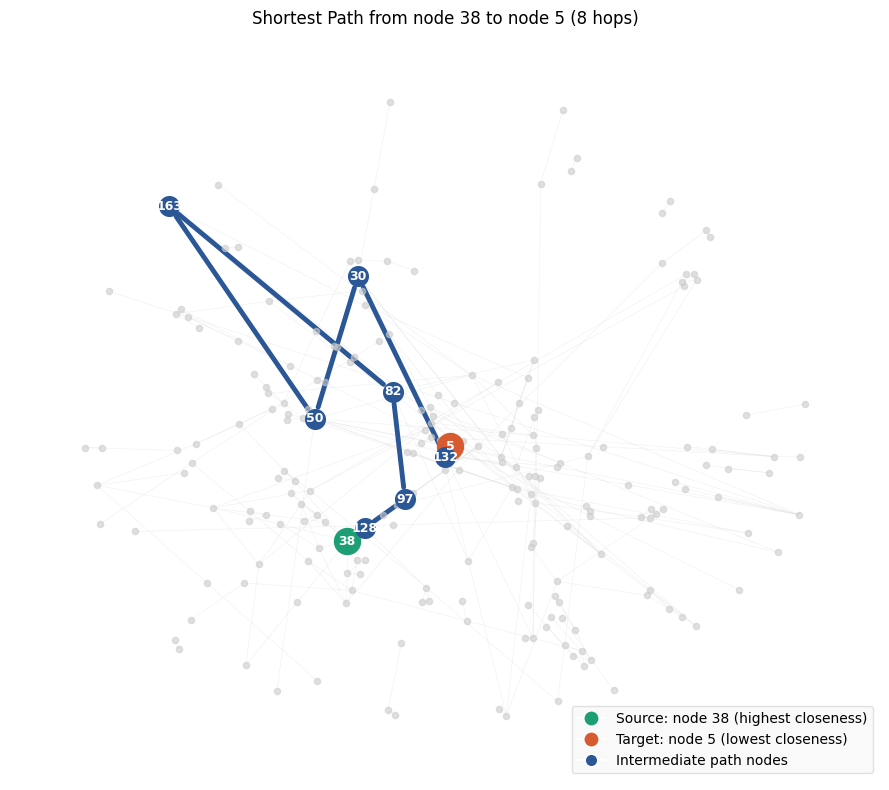

In [30]:
fig, ax = plt.subplots(figsize=(9, 8))

path_edges = list(zip(path[:-1], path[1:]))

# All edges — dim
nx.draw_networkx_edges(graph_used, POS, ax=ax, edge_color='#e0e0e0',
                       arrows=False, width=0.4, alpha=0.5)

# All nodes — dim
nx.draw_networkx_nodes(graph_used, POS, ax=ax, node_size=20,
                       node_color='#cccccc', alpha=0.6)

# Highlighted path edges — thick blue
nx.draw_networkx_edges(graph_used, POS, ax=ax, edgelist=path_edges,
                       edge_color='#2b5797', width=3.5,
                       arrows=True, arrowsize=14)

# Path nodes — colored by role
nx.draw_networkx_nodes(graph_used, POS, ax=ax, nodelist=[source],
                       node_size=350, node_color='#1d9e75')
nx.draw_networkx_nodes(graph_used, POS, ax=ax, nodelist=[target],
                       node_size=350, node_color='#d85a30')
intermediate = [n for n in path if n not in [source, target]]
if intermediate:
    nx.draw_networkx_nodes(graph_used, POS, ax=ax, nodelist=intermediate,
                           node_size=200, node_color='#2b5797')

# Labels on path nodes
nx.draw_networkx_labels(graph_used, POS, ax=ax,
                        labels={n: str(n) for n in path},
                        font_size=9, font_color='white', font_weight='bold')

legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1d9e75',
           markersize=11, label=f'Source: node {source} (highest closeness)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#d85a30',
           markersize=11, label=f'Target: node {target} (lowest closeness)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2b5797',
           markersize=9, label='Intermediate path nodes'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='#dddddd')

ax.set_title(
    f"Shortest Path from node {source} to node {target} ({len(path)-1} hops)",
    fontsize=12, pad=10
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("shortest_path.png", dpi=150, bbox_inches='tight')
plt.show()

> 🔍 **Why this matters**: In a social/epidemiological context, the shortest path between nodes represents the fastest route through which information, behaviors, or disease could theoretically spread. Nodes along short paths between high- and low-centrality individuals are **critical bridges** — removing them would dramatically increase the graph's diameter and slow diffusion.

---

## Part 8: Multi-Panel Summary Figure

A final synthesis: combine all four network views — degree, clustering, closeness, and betweenness — into a single **multi-panel figure** using `node_size` mapped to degree and `node_color` mapped to each metric. This is a technique highlighted in the course: **layering multiple encoding channels** to communicate more information in a single view.

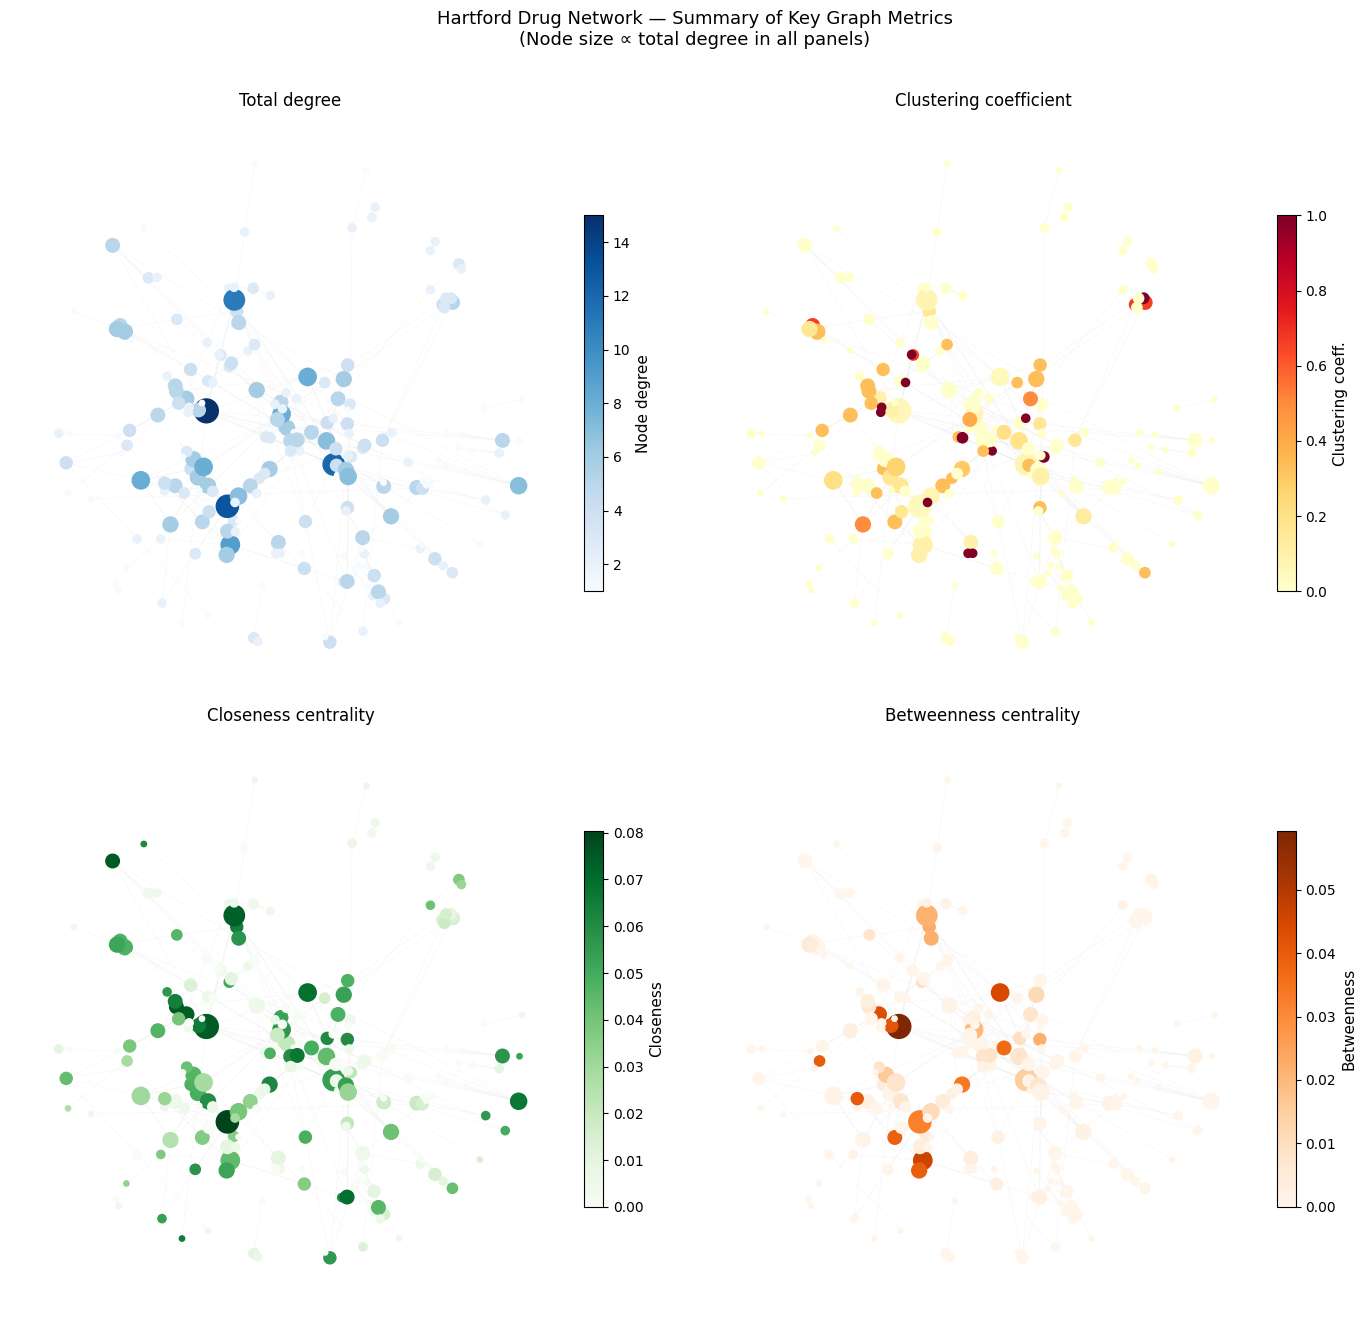

Saved: summary_panel.png


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 13))
axes = axes.flatten()

# Normalize total degree for node size encoding
degrees_arr = np.array([total_degree[n] for n in G.nodes()])
sizes = 15 + 280 * (degrees_arr - degrees_arr.min()) / (degrees_arr.max() - degrees_arr.min() + 1e-8)

# Panels configuration
panels = [
    ("Total degree",
     degrees_arr, plt.cm.Blues, "Total degree"),
    ([clustering[n] for n in G.nodes()],
     None, plt.cm.YlOrRd, "Clustering coefficient"),
    ([closeness[n] for n in G.nodes()],
     None, plt.cm.Greens, "Closeness centrality"),
    ([betweenness[n] for n in G.nodes()],
     None, plt.cm.Oranges, "Betweenness centrality"),
]

metric_labels = [
    ("Total degree",           degrees_arr,
     plt.cm.Blues,   "Node degree"),
    ("Clustering coefficient", [clustering[n]   for n in G.nodes()],
     plt.cm.YlOrRd,  "Clustering coeff."),
    ("Closeness centrality",   [closeness[n]    for n in G.nodes()],
     plt.cm.Greens,  "Closeness"),
    ("Betweenness centrality", [betweenness[n]  for n in G.nodes()],
     plt.cm.Oranges, "Betweenness"),
]

for ax, (title, values, cmap, cbar_label) in zip(axes, metric_labels):
    nx.draw_networkx_edges(G, POS, ax=ax, edge_color='#e8e8e8',
                           arrows=False, width=0.35, alpha=0.45)
    sc = nx.draw_networkx_nodes(G, POS, ax=ax,
                                node_color=values, node_size=sizes,
                                cmap=cmap)
    plt.colorbar(sc, ax=ax, shrink=0.65, pad=0.02, label=cbar_label)
    ax.set_title(title, fontsize=12, pad=6)
    ax.set_axis_off()

fig.suptitle(
    "Hartford Drug Network — Summary of Key Graph Metrics\n"
    "(Node size ∝ total degree in all panels)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig("summary_panel.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: summary_panel.png")

---

## Part 9: Bonus — The Les Misérables Network (PCA Dataset)

From **PCA 21**, we also worked with the **Les Misérables co-appearance network** — a weighted, undirected graph where nodes are characters and edges represent co-appearances. This is a great example of a **named, real-world network** where node labels are meaningful.

Here we enhance the PCA visualization by scaling node size to weighted degree (how many co-appearances total).

In [34]:
try:
    LM = nx.read_gml("lesmis.gml")
    print(f"Les Misérables network: {LM.number_of_nodes()} nodes, {LM.number_of_edges()} edges")

    # Weighted degree for size encoding
    lm_wdeg = dict(LM.degree(weight='value'))
    lm_sizes = np.array([lm_wdeg[n] for n in LM.nodes()])
    lm_sizes_scaled = 40 + 600 * (lm_sizes - lm_sizes.min()) / (lm_sizes.max() - lm_sizes.min() + 1e-8)

    # Betweenness for color
    lm_btw = nx.betweenness_centrality(LM, weight='value')
    lm_btw_vals = [lm_btw[n] for n in LM.nodes()]

    fig, ax = plt.subplots(figsize=(13, 11))
    lm_pos = nx.spring_layout(LM, seed=7, weight='value')

    # Edges — width ∝ weight
    edge_weights = [LM[u][v].get('value', 1) for u, v in LM.edges()]
    max_w = max(edge_weights)
    nx.draw_networkx_edges(LM, lm_pos, ax=ax,
                           width=[0.3 + 2.5 * w/max_w for w in edge_weights],
                           edge_color='#cccccc', alpha=0.6)

    # Nodes — size ∝ degree, color ∝ betweenness
    sc = nx.draw_networkx_nodes(LM, lm_pos, ax=ax,
                                node_size=lm_sizes_scaled,
                                node_color=lm_btw_vals,
                                cmap=plt.cm.YlOrRd)
    plt.colorbar(sc, ax=ax, shrink=0.6, label='Betweenness centrality')

    # Labels for top-degree nodes only
    top_nodes = sorted(lm_wdeg, key=lm_wdeg.get, reverse=True)[:12]
    nx.draw_networkx_labels(LM, lm_pos, ax=ax,
                            labels={n: n for n in top_nodes},
                            font_size=8, font_weight='bold')

    ax.set_title(
        "Les Misérables Co-appearance Network\n"
        "Node size ∝ weighted degree · Node color ∝ betweenness centrality · Edge width ∝ co-appearances",
        fontsize=11, pad=10
    )
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig("lesmis_enhanced.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: lesmis_enhanced.png")

except FileNotFoundError:
    print("lesmis.gml not found in current directory. Download from the NetworkX datasets or the course repo.")
    print("You can get it at: https://raw.githubusercontent.com/networkx/networkx/main/networkx/generators/atlas.py")

lesmis.gml not found in current directory. Download from the NetworkX datasets or the course repo.
You can get it at: https://raw.githubusercontent.com/networkx/networkx/main/networkx/generators/atlas.py


---
## Conclusion

This tutorial showed how network visualization can be used not just to display relationships, but to support interpretation through design.

By applying centrality measures, clustering, and layout strategies, we can better understand the structure of a network. More importantly, visualization choices such as layout, color, and size play a key role in making these patterns visible.

Overall, this tutorial connects technical NetworkX workflows with visualization principles from the course, demonstrating how design decisions influence what we are able to see and understand.


## Summary & Key Takeaways

This tutorial has walked through a complete network visualization workflow in NetworkX. Here's a quick reference of what we covered:

| Topic | Key function(s) | Visual encoding |
|---|---|---|
| Load directed graph | `nx.read_edgelist(..., create_using=nx.DiGraph())` | — |
| Layout comparison | `nx.spring_layout`, `nx.circular_layout`, `nx.kamada_kawai_layout` | Node position |
| Degree distribution | `G.in_degree()`, `G.out_degree()` | Histogram |
| Clustering coefficient | `nx.clustering(G.to_undirected())` | Node color (sequential) |
| Closeness centrality | `nx.closeness_centrality(G)` | Node color (sequential) |
| Betweenness centrality | `nx.betweenness_centrality(G)` | Node color (sequential) |
| Shortest path | `nx.shortest_path(G, source, target)` | Edge width + node color |
| Weighted network | `G.degree(weight='value')` | Node size + edge width |

### Design principles applied

- **Layout algorithm choice** directly affects what structures are visible — spring layout is best for community detection
- **Redundant encoding** (size + color together) makes important nodes preattentively salient
- **Sequential colormaps** (Blues, YlOrRd) are appropriate for continuous positive quantities
- **Edge width** can encode weight in weighted graphs
- **Multi-panel figures** allow comparison of different metrics in a consistent visual context

### Where to go next

- **Interactive visualization**: Try [Pyvis](https://pyvis.readthedocs.io/) or [Plotly](https://plotly.com/python/network-graphs/) for interactive, zoomable network graphs
- **Community detection**: `nx.community.greedy_modularity_communities()` to find clusters algorithmically
- **Graphviz layouts**: For hierarchical graphs, Graphviz's `dot` and `neato` engines often produce cleaner layouts — try `from networkx.drawing.nx_agraph import graphviz_layout`
- **Large networks**: For networks with 10,000+ nodes, consider [graph-tool](https://graph-tool.skewed.de/) or [igraph](https://python.igraph.org/)

---

*Tutorial developed for CMSE 402 Honors Option — Spring 2026*